In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch. device("cuda:0" if torch. cuda. is_available() else "cpu")

In [3]:
train_dataset = torchvision.datasets. FashionMNIST("…./chap05/data", download=True,transform=transforms. Compose([ transforms. ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.9MB/s]


In [4]:
test_dataset = torchvision.datasets. FashionMNIST("…./chap05/data", download=True,train=False,transform=transforms. Compose([ transforms. ToTensor()]))

In [5]:
train_loader = torch.utils.data. DataLoader(train_dataset,batch_size=100,shuffle=True)
test_loader = torch.utils.data. DataLoader (test_dataset,batch_size=100)

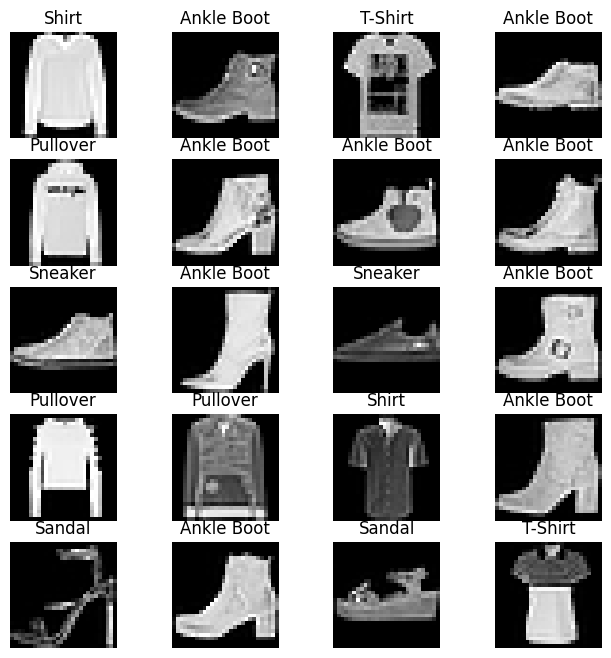

In [6]:
labels_map = {0 : "T-Shirt", 1: 'Trouser', 2 : 'Pullover',
5 : 'Sandal', 6 : 'Shirt',7 : 'Sneaker', 3 : 'Dress', 4: 'Coat', 8: 'Bag', 9 : 'Ankle Boot'}
5

fig = plt. figure(figsize=(8,8)); columns = 4;
rows = 5;
for i in range(1, columns*rows +1):
  img_xy = np. random. randint(len(train_dataset)); # 임의의 숫자 출력
  img = train_dataset[img_xy][0][0,:,:] #3차원의 배열을 형성함. 저거에 해당하는 요소르 갑고 오겠다는 의미로 보면 됨.
  fig. add_subplot (rows, columns, i)
  plt. title(labels_map[train_dataset [img_xy][1]])
  plt.axis('off')
  plt. imshow(img, cmap= 'gray')
plt.show()

In [7]:
# 심층 신경망 모델 형성.
class FashionDNN (nn.Module) :
  def __init__(self):
    super (FashionDNN, self).__init__()
    self.fc1 = nn. Linear (in_features=784, out_features=256) #nn은 딥러닝 모델 구성에 필요한 모듈이 모여있음.
    self.drop = nn. Dropout (0.25)
    self. fc2 = nn. Linear(in_features=256, out_features=128) #in은 입력 크기, out 은 출력 크기임.
    self. fc3 = nn. Linear(in_features=128, out_features=10)

  def forward (self, input_data) : #즉 , f o r W a r d ( ) 는 모 델 이 학 습 데 이 터 를 입력 받 아 서 순 전 파 연 산 을 진 행 하 는 함 수
    out = input_data. view(-1, 784) # 텐서의 크기를 변경해주는 역할. -1은 파이토치 맘대로, 두번째차원은 784를 가지라는 말.
    out = F.relu(self.fc1(out)) # 함수를 사용하는 위치 지정.
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self. fc3(out)
    return out

In [8]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)
criterion = nn. CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:


num_epochs = 5
count = 0

loss_list      = []
iteration_list = []
accuracy_list  = []

predictions_list = []
labels_list      = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train  = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss    = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total   = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test        = Variable(images.view(100, 1, 28, 28))
                outputs     = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total   += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%"
                  .format(count, loss.data, accuracy))


# ════════════════════════════════════════════════════════════════
# [코드 5-9] 합성곱(CNN) 네트워크 생성 (p.193)
# ════════════════════════════════════════════════════════════════

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1  = nn.Linear(in_features=64*6*6, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2  = nn.Linear(in_features=600, out_features=120)
        self.fc3  = nn.Linear(in_features=120, out_features=10)
        # 마지막 계층의 out_features는 클래스 개수를 의미

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out


# ════════════════════════════════════════════════════════════════
# [코드 5-10] 합성곱 네트워크를 위한 파라미터 정의 (p.197)
# ════════════════════════════════════════════════════════════════

learning_rate = 0.001
model         = FashionCNN()

model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)


# ════════════════════════════════════════════════════════════════
# [코드 5-11] CNN 모델 학습 및 성능 평가 (p.198~199)
# ════════════════════════════════════════════════════════════════

num_epochs = 5
count = 0

loss_list      = []
iteration_list = []
accuracy_list  = []

predictions_list = []
labels_list      = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train  = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss    = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total   = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test        = Variable(images.view(100, 1, 28, 28))
                outputs     = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total   += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%"
                  .format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5157454013824463, Accuracy: 83.57999420166016%
Iteration: 1000, Loss: 0.29626965522766113, Accuracy: 85.0%
Iteration: 1500, Loss: 0.3896326720714569, Accuracy: 84.61000061035156%
Iteration: 2000, Loss: 0.3173910975456238, Accuracy: 85.98999786376953%
Iteration: 2500, Loss: 0.3315642178058624, Accuracy: 86.23999786376953%
Iteration: 3000, Loss: 0.1771845817565918, Accuracy: 87.0199966430664%
FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.3966410756111145, Accuracy: 87.37999725341797%
Iteration: 1000, Loss: 0.35508596897125244, Accuracy: 88.95999908447266%
Iteration: 1500, Loss: 0.314098596572876, Accuracy: 89.6500015258789%
Iteration: 2000, Loss: 0.19666467607021332, Accuracy: 89.63999938964844%
Iteration: 2500, Loss: 0.20285385847091675, Accuracy: 89.98999786376953%
Iteration: 3000, Loss: 0.17464318871498108, Accuracy: 89.79999542236328%
